# 01️⃣ Exploratory Data Analysis

This notebook loads the NIFTY‑50 parquet data and provides a quick overview of its structure and basic statistics.

In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, pathlib, os
%matplotlib inline


In [2]:
# Get absolute directory of the current notebook (works with both notebook and script formats)
NOTEBOOK_DIR = pathlib.Path(os.path.abspath('') if '__file__' not in locals() else os.path.dirname(__file__))
PROJECT_ROOT = NOTEBOOK_DIR.parent
parquet_path = PROJECT_ROOT / 'data' / 'parquet'
files = list(parquet_path.glob('*.parquet'))
print(f'Found {len(files)} parquet files in {parquet_path}')
if files:
    # Let's load the NIFTY50 aggregated parquet if it exists, otherwise the first file
    nifty_all = [f for f in files if 'NIFTY50_all' in f.name]
    target_file = nifty_all[0] if nifty_all else files[0]
    print(f'Loading {target_file.name} for inspection...')
    df = pd.read_parquet(target_file)
    display(df.head())
else:
    df = None
    print('No parquet files found. Check data conversion.')


Found 58 parquet files in C:\Users\sajal\cult project\netflix\data\parquet
Loading NIFTY50_all.parquet for inspection...


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278.0,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678.0,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913.0,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123.0,0.2741


In [3]:
# Basic info
if df is not None:
    print(df.info())
    print('Describe:')
    display(df.describe())
else:
    print('Skipping info because df is not loaded.')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235192 entries, 0 to 235191
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Date                235192 non-null  object 
 1   Symbol              235192 non-null  object 
 2   Series              235192 non-null  object 
 3   Prev Close          235192 non-null  float64
 4   Open                235192 non-null  float64
 5   High                235192 non-null  float64
 6   Low                 235192 non-null  float64
 7   Last                235192 non-null  float64
 8   Close               235192 non-null  float64
 9   VWAP                235192 non-null  float64
 10  Volume              235192 non-null  int64  
 11  Turnover            235192 non-null  float64
 12  Trades              120344 non-null  float64
 13  Deliverable Volume  219115 non-null  float64
 14  %Deliverble         219115 non-null  float64
dtypes: float64(11), int64(1), object(3

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,235192.000000,235192.000000,235192.000000,235192.000000,235192.000000,235192.000000,235192.00000,2.351920e+05,2.351920e+05,1.203440e+05,2.191150e+05,219115.000000
mean,1266.196349,1267.759708,1286.581440,1247.488465,1266.388302,1266.554351,1267.13230,3.045903e+06,1.610138e+14,6.196427e+04,1.315098e+06,0.502997
std,2581.370320,2585.259609,2619.649216,2546.621396,2581.392543,2582.140942,2582.69998,7.333981e+06,3.298085e+14,6.866457e+04,2.831670e+06,0.190019
min,0.000000,8.500000,9.750000,8.500000,9.100000,9.150000,9.21000,3.000000e+00,1.047000e+07,1.100000e+01,5.000000e+00,0.023600
25%,274.300000,275.000000,279.500000,269.600000,274.400000,274.350000,274.69750,2.190095e+05,1.612816e+13,2.183400e+04,1.253830e+05,0.364700
50%,566.500000,567.025000,576.900000,556.500000,567.000000,566.700000,566.94000,1.010938e+06,6.832603e+13,4.406800e+04,5.017560e+05,0.511000
75%,1242.200000,1243.312500,1263.000000,1221.650000,1242.900000,1242.400000,1242.66250,3.019851e+06,1.863835e+14,7.893550e+04,1.452233e+06,0.638400
max,32861.950000,33399.950000,33480.000000,32468.100000,32849.000000,32861.950000,32975.24000,4.810589e+08,3.564334e+16,1.643015e+06,2.325307e+08,1.000000


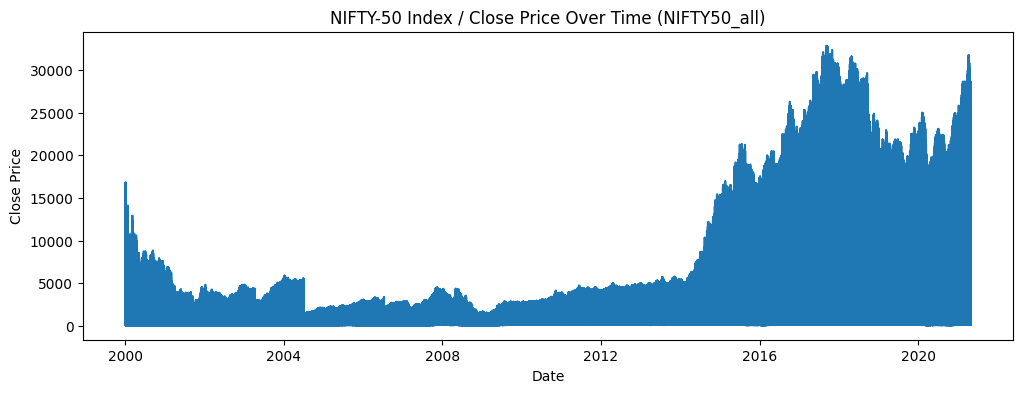

In [4]:
# Plot closing price over time
if df is not None and 'Close' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df_sorted = df.sort_values('Date')
    plt.figure(figsize=(12,4))
    plt.plot(df_sorted['Date'], df_sorted['Close'])
    plt.title(f'NIFTY-50 Index / Close Price Over Time ({target_file.stem})')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    # Save plot to outputs directory
    output_dir = PROJECT_ROOT / 'outputs'
    output_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_dir / 'eda_close_price.png')
    plt.show()
else:
    print('Skipping plot because df or Close column is not loaded.')
